In [1]:
import pandas as pd
df_train = pd.read_csv('train.csv', sep=None, engine='python')
df_test = pd.read_csv('test.csv', sep=None, engine='python')

In [2]:
df_train.head()

,id,dt,target,turn_cur_cr_avg_act_v2,salary_6to12m_avg,hdb_bki_total_max_limit,dp_ils_paymentssum_avg_12m,hdb_bki_total_cc_max_limit,incomeValue,gender,...,dp_ils_uniq_companies_1y,avg_6m_travel,avg_6m_government_services,hdb_bki_active_cc_max_overdue,total_rur_amt_cm_avg_period_days_ago_v2,label_Above_1M_share_r1,transaction_category_supermarket_sum_cnt_d15,max_balance_rur_amt_1m_af,w,first_salary_income
0,2,2024-04-30,"109324,47632478633","1465144,96",NaN,52800.0,"365346,244633755",23213.0,"97366,0",Женский,...,"1,0","0,0","57,0",0.0,"297,0","0,02702702702702703","9,0",NaN,"0,3012172807640372",NaN
1,4,2024-02-29,"25558,02866242038","303593,66",NaN,260200.0,NaN,10000.0,"32580,0",Женский,...,NaN,"0,0","707,0",67.0,"30245,0",NaN,"2,0",NaN,"0,6957996079578388",NaN
2,5,2024-02-29,"40666,753097982706","490754,01",NaN,2000000.0,NaN,90000.0,"96866,0",Женский,...,NaN,"422,0","0,0",0.0,"210322,0","0,0","20,0",NaN,"0,5159704060557002",NaN
3,6,2024-04-30,"43856,67205839414","219875,12",NaN,75000.0,NaN,75000.0,"43860,0",Мужской,...,NaN,"0,0","0,0",0.0,"7187,0","0,0","7,0",NaN,"0,4780029003784456",NaN
4,7,2024-04-30,"130420,85199232883","1750241,8449999997",NaN,1000000.0,NaN,240000.0,"83815,0",Женский,...,NaN,"0,0","84,0",0.0,"690038,0","0,0","9,0",NaN,"0,5523135540134384",NaN


In [3]:
df_test.head()

,id,dt,turn_cur_cr_avg_act_v2,salary_6to12m_avg,hdb_bki_total_max_limit,dp_ils_paymentssum_avg_12m,hdb_bki_total_cc_max_limit,incomeValue,gender,avg_cur_cr_turn,...,total_sum,dp_ils_uniq_companies_1y,avg_6m_travel,avg_6m_government_services,hdb_bki_active_cc_max_overdue,total_rur_amt_cm_avg_period_days_ago_v2,label_Above_1M_share_r1,transaction_category_supermarket_sum_cnt_d15,max_balance_rur_amt_1m_af,first_salary_income
0,0,2024-08-31,"805319,38",NaN,61137.47,NaN,60000.0,"159999,0",Женский,"69740,0",...,NaN,NaN,"0,0","0,0",NaN,"80228,0","0,0","1,0",NaN,NaN
1,1,2024-10-31,"306240,0",NaN,949500.00,NaN,230000.0,"108834,0",Мужской,"63513,0",...,"0,0",NaN,"0,0","0,0",0.0,"24888,0","0,0",NaN,NaN,NaN
2,3,2024-09-30,"164908,72999999998",NaN,178000.00,NaN,178000.0,"59203,0",Женский,"132,0",...,"38630,630000000005",NaN,"0,0","0,0",2363.9,"223,0",NaN,NaN,NaN,NaN
3,9,2024-10-31,"2374846,42",NaN,25500.00,"126247,44835851202",4999.0,"180906,0",Женский,"290339,0",...,NaN,"3,0","800,0","0,0",NaN,"25734,0","0,0","7,0","0,0",NaN
4,11,2024-11-30,"735902,71","47828,145620567375",60000.00,NaN,60000.0,"24922,0",Мужской,"76924,0",...,"0,0",NaN,"0,0","0,0",0.0,"1214,0","0,0","15,0",NaN,NaN


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [5]:
print(f"Размер train: {df_train.shape}")
print(f"Размер test: {df_test.shape}")

Размер train: (76786, 224)
Размер test: (73214, 222)


In [6]:
#Проверка совпадения признаков в train и test
train_cols = set(df_train.columns)
test_cols = set(df_test.columns)
print("Признаки только в train (их нет в test):")
print(train_cols - test_cols)
print("Признаки только в test (их нет в train):")
print(test_cols - train_cols)
print(f"Количество общих признаков: {len(train_cols & test_cols)}")
#Таргет и веса - логично

Признаки только в train (их нет в test):
{'target', 'w'}
Признаки только в test (их нет в train):
set()
Количество общих признаков: 222


In [7]:
#Типы признаков
#Категориальные признаки
cat_cols = ['gender', 'adminarea', 'city_smart_name', 'incomeValueCategory',
            'dp_ewb_last_employment_position', 'dp_ewb_last_organization', 'addrref']

#Бинарные
binary_cols = ['blacklist_flag', 'client_active_flag', 'nonresident_flag',
               'accountsalary_out_flag']

#Все признаки, начинающиеся с vert_has_app_ru_ - бинарные (есть приложение или нет)
vert_app_cols = [col for col in df_train.columns if col.startswith('vert_has_app_ru_')]
binary_cols.extend(vert_app_cols)

#Количественные признаки - где 0 это реальное значение, а не пропуск
count_cols = ['pil', 'loan_cnt', 'bki_total_products', 'bki_total_auto_cnt',
              'bki_total_ip_cnt', 'bki_total_oth_cnt', 'hdb_bki_total_cnt',
              'hdb_bki_total_products', 'hdb_bki_total_active_products',
              'bki_total_active_products', 'hdb_bki_active_pil_cnt',
              'hdb_bki_total_micro_cnt', 'hdb_bki_total_pil_cnt',
              'acard', 'other_credits_count', 'winback_cnt', 'mob_cnt_days',
              'mob_total_sessions', 'calledCtnOutGroup', 'businessTelSubs', 'label_Below_50k_share_r1', 'label_500k_to_1M_share_r1', 'label_Above_1M_share_r1']

In [8]:
#Анализ пропусков
#Пропуски могут сильно влиять на качество модели, их нужно выявить
missing_train = (df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)
missing_test = (df_test.isnull().sum() / len(df_test) * 100).sort_values(ascending=False)

print("Топ-30 переменных по количеству пропусков в train:")
print(missing_train[missing_train > 0].head(30))
print(f"Признаков с >50% пропусков в train: {(missing_train > 50).sum()}")
print(f"Признаков с >50% пропусков в test: {(missing_test > 50).sum()}")

#Количество с пропусками
row_missing = df_train.isnull().sum(axis=1)
print(f"Строк без пропусков: {(row_missing == 0).sum()}")
print(f"Строк с >50% пропусков: {(row_missing > len(df_train.columns)/2).sum()}")

Топ-30 переменных по количеству пропусков в train:
avg_by_category__amount__sum__cashflowcategory_name__platezhi_cherez_internet            98.441122
turn_fdep_db_avg_act_v2                                                                  96.972104
turn_fdep_db_sum_v2                                                                      95.004298
turn_fdep_db_avg_v2                                                                      95.004298
avg_by_category__amount__sum__cashflowcategory_name__reklama_v_internete                 93.199281
avg_by_category__amount__sum__cashflowcategory_name__zarubezhnye_finansovye_operatsii    92.748678
dp_payoutincomedata_payout_avg_prev_year                                                 89.749433
first_salary_income                                                                      88.711484
avg_by_category__amount__sum__cashflowcategory_name__oteli                               88.460136
by_category__amount__sum__eoperation_type_name__perevod_s_

In [9]:
#83 признака имеют больше 50% пропусков
#Нет ни одной полной записи - у каждого клиента чего-то не хватает
#Самые проблемные - платежи через интернет (98% пустых), депозитные счета (95-97%), цифровой профиль (80-90%)

In [10]:
df_train.dtypes

id                                               int64
dt                                              object
target                                          object
turn_cur_cr_avg_act_v2                          object
salary_6to12m_avg                               object
                                                 ...  
label_Above_1M_share_r1                         object
transaction_category_supermarket_sum_cnt_d15    object
max_balance_rur_amt_1m_af                       object
w                                               object
first_salary_income                             object
Length: 224, dtype: object

In [11]:
#Анализ целевой переменной
df_train['target'] = df_train['target'].astype(str).str.replace(',', '.').astype(float)
#Целевая переменная - доход клиента
print(f"Целевая переменная (target):")
print(df_train['target'].describe())
print("-"*20)

#Квантили показывают распределение дохода по разным группам клиентов
print("Квантили target:")
for q in [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"  {q*100:>3.0f}%: {df_train['target'].quantile(q):>10.2f}")

#Распределение
mean_income = df_train['target'].mean()
median_income = df_train['target'].median()
print("-"*20)

print(f"Среднее: {mean_income:.2f}")
print("-"*20)
print(f"Медиана: {median_income:.2f}")
print("-"*20)

if mean_income > median_income * 1.1:
    print("Доход смещен вправо (большинство имеют низкий/средний доход, меньшинство - очень высокий)")
elif mean_income < median_income * 0.9:
    print("Доход смещен влево (большинство имеют высокий доход, меньшинство - очень низкий)")
else:
    print("Симметрично")
print("-"*20)

#Сегменты
a = [0, 30000, 50000, 80000, 120000, 200000, 500000, float('inf')]
a_name = ['до 30 тыс', '30-50 тыс', '50-80 тыс', '80-120 тыс', '120-200 тыс', '200-500 тыс', 'более 500 тыс']
df_train['income_segment'] = pd.cut(df_train['target'], bins=a, labels=a_name)

print("Распределение по сегментам дохода:")
print(df_train['income_segment'].value_counts().sort_index())
print("-"*20)
print("Распределение по сегментам дохода в процентах:")
print((df_train['income_segment'].value_counts(normalize=True).sort_index() * 100).round(1))

Целевая переменная (target):
count    7.678600e+04
mean     9.264824e+04
std      1.124090e+05
min      2.000000e+04
25%      3.970997e+04
50%      6.275413e+04
75%      1.002017e+05
max      1.500000e+06
Name: target, dtype: float64
--------------------
Квантили target:
    1%:   20406.58
    5%:   22711.57
   10%:   26201.31
   25%:   39709.97
   50%:   62754.13
   75%:  100201.68
   90%:  171206.68
   95%:  256074.61
   99%:  596585.06
--------------------
Среднее: 92648.24
--------------------
Медиана: 62754.13
--------------------
Доход смещен вправо (большинство имеют низкий/средний доход, меньшинство - очень высокий)
--------------------
Распределение по сегментам дохода:
income_segment
до 30 тыс        11237
30-50 тыс        15945
50-80 тыс        22171
80-120 тыс       13078
120-200 тыс       8430
200-500 тыс       4868
более 500 тыс     1057
Name: count, dtype: int64
--------------------
Распределение по сегментам дохода в процентах:
income_segment
до 30 тыс        14.6
30-50

In [12]:
#Средний доход - 92 648 руб., медиана - 62 754 руб. (среднее сильно выше медианы из-за богатых клиентов)
#Разброс - от 20 000 до 1 500 000 руб.
#Распределение смещено вправо: 80% клиентов зарабатывают до 120 000 руб., и только 1.4% - больше 500 000 руб
#Основная масса (57%) - это люди с доходом 30-80 тыс. руб.
#Меньше 30 тыс. - 14.6% клиентов (самые бедные)

In [13]:
#Анализ весов
#Веса используются в метрике WMAE (поэтому важно их распределение)
df_train['w'] = df_train['w'].astype(str).str.replace(',', '.').astype(float)
print(f"Веса (w): {df_train['w'].describe()}")
print("Квантили весов:")
for q in [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"  {q*100:>3.0f}%: {df_train['w'].quantile(q):>10.2f}")
#Корреляция веса с доходом
print(f"Корреляция веса с target: {df_train['w'].corr(df_train['target']):.4f}")

Веса (w): count    76786.000000
mean         0.569014
std          0.551835
min          0.000021
25%          0.235950
50%          0.449424
75%          0.680337
max          2.570703
Name: w, dtype: float64
Квантили весов:
    1%:       0.01
    5%:       0.05
   10%:       0.10
   25%:       0.24
   50%:       0.45
   75%:       0.68
   90%:       1.04
   95%:       2.05
   99%:       2.57
Корреляция веса с target: 0.7161


In [14]:
#Веса распределены от 0 до 2.57, средний - 0.57
#Богатые клиенты имеют больший вес в метрике WMAE. Ошибки в предсказании дохода для богатых будут сильнее штрафоваться
#Корреляция веса с доходом = 0.72 - это очень сильная связь
#Признаки БКИ (кредитные лимиты) очень похожи друг на друга (корреляция высокая)

# 1. Корреляция всех признаков с target
corr_target = df_train.select_dtypes(include=[np.number]).corr()['target'].sort_values(ascending=False)

print("Топ-10 признаков, коррелирующих с target (доходом):")
print(corr_target.head(10))

# 2. Корреляция всех признаков с w (вес)
corr_weight = df_train.select_dtypes(include=[np.number]).corr()['w'].sort_values(ascending=False)

print("\nТоп-10 признаков, коррелирующих с w (вес):")
print(corr_weight.head(10))

Топ-10 признаков, коррелирующих с target (доходом):
target                                 1.000000
w                                      0.716114
bki_total_il_max_limit                 0.439320
hdb_bki_active_pil_max_limit           0.431737
hdb_bki_total_pil_max_limit            0.415267
hdb_bki_total_ip_max_limit             0.411488
hdb_bki_total_max_limit                0.396184
hdb_bki_active_cc_max_limit            0.366439
hdb_bki_total_cc_max_limit             0.334585
hdb_bki_other_active_ip_outstanding    0.329312
Name: target, dtype: float64

Топ-10 признаков, коррелирующих с w (вес):
w                                      1.000000
target                                 0.716114
hdb_bki_total_ip_max_limit             0.377296
bki_total_il_max_limit                 0.367391
hdb_bki_active_pil_max_limit           0.354469
hdb_bki_total_pil_max_limit            0.342296
hdb_bki_total_max_limit                0.331197
hdb_bki_active_cc_max_limit            0.312254
hdb_bki_oth

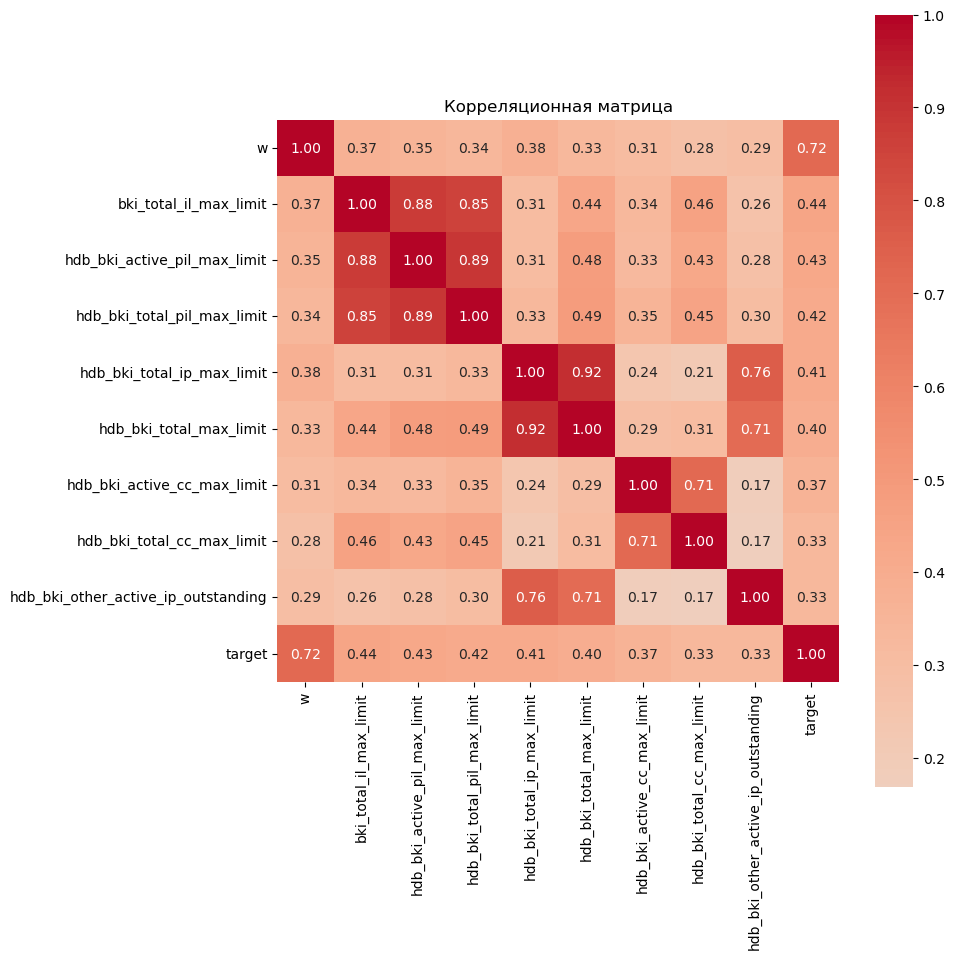

In [15]:
#Корреляционная матрица (топ-10 признаков)
corr_with_target = df_train.select_dtypes(include=[np.number]).corr()['target'].sort_values(ascending=False)
top_10 = corr_with_target.head(10).index.tolist()
if 'target' in top_10:
    top_10.remove('target')

plt.figure(figsize=(10, 10))
corr_matrix = df_train[top_10 + ['target']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

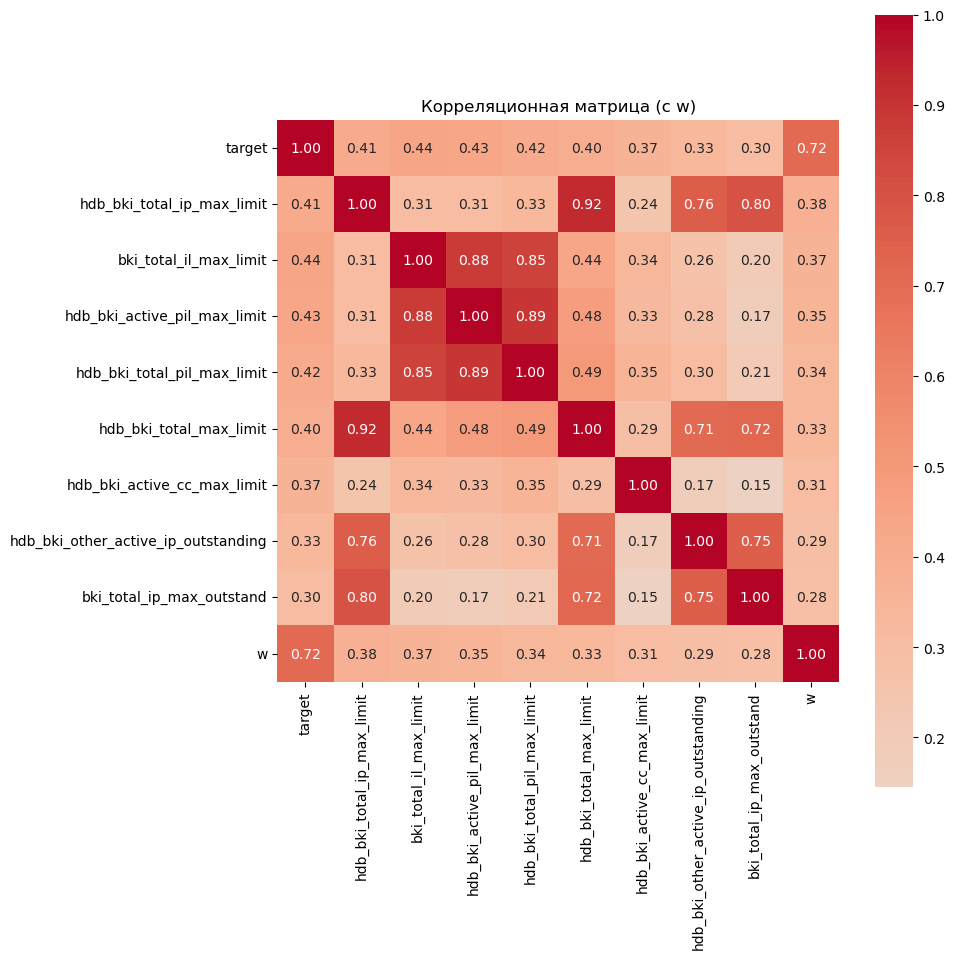

In [16]:
#Корреляция с w
corr_with_weight = df_train.select_dtypes(include=[np.number]).corr()['w'].sort_values(ascending=False)
top_10_weight = corr_with_weight.head(10).index.tolist()
if 'w' in top_10_weight:
    top_10_weight.remove('w')

plt.figure(figsize=(10, 10))
corr_matrix_weight = df_train[top_10_weight + ['w']].corr()
sns.heatmap(corr_matrix_weight, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Корреляционная матрица (с w)')
plt.tight_layout()
plt.show()

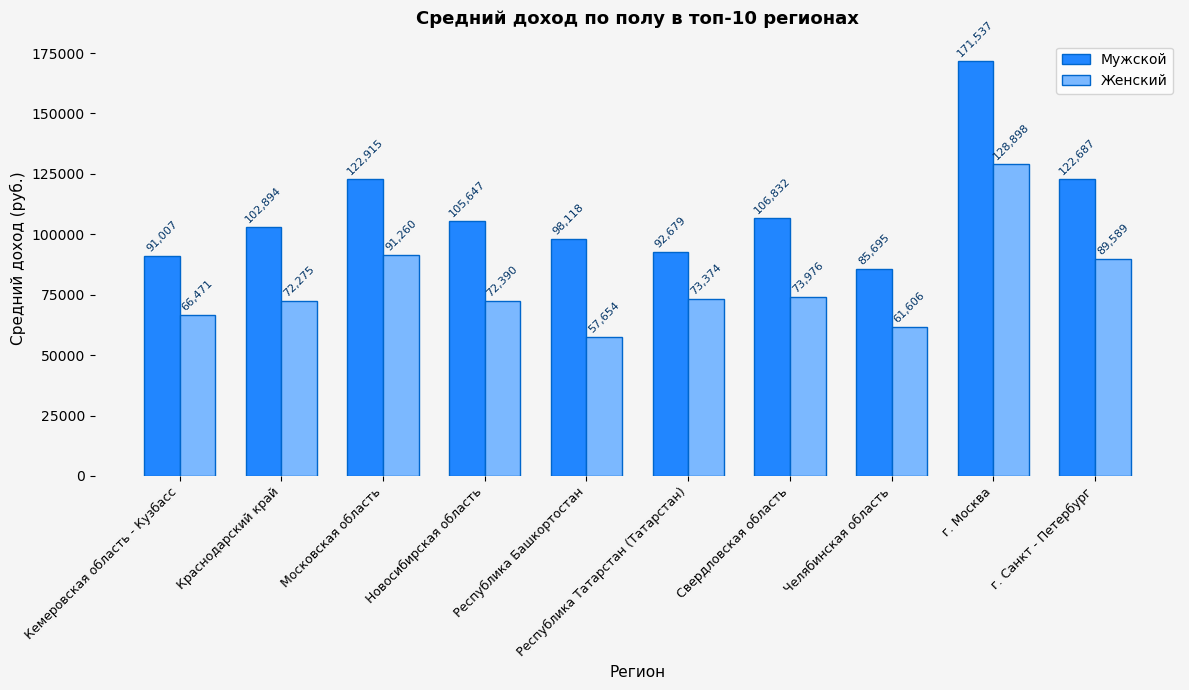

In [17]:
top_regions = df_train['adminarea'].value_counts().head(10).index
region_gender_income = df_train[df_train['adminarea'].isin(top_regions)].groupby(['adminarea', 'gender'])['target'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#F5F5F5')
ax.set_facecolor('#F5F5F5')

x = np.arange(len(region_gender_income.index))
width = 0.35
bars1 = ax.bar(x - width/2, region_gender_income['Мужской'], width, 
               label='Мужской', color='#2186FF', edgecolor='#0066CC', linewidth=1)
bars2 = ax.bar(x + width/2, region_gender_income['Женский'], width, 
               label='Женский', color='#7BB8FF', edgecolor='#0066CC', linewidth=1)

ax.set_xlabel('Регион', fontsize=11)
ax.set_ylabel('Средний доход (руб.)', fontsize=11)
ax.set_title('Средний доход по полу в топ-10 регионах', fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(region_gender_income.index, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1000,
            f'{height:,.0f}', ha='center', va='bottom', fontsize=8, rotation=45, color='#003366')
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1000,
            f'{height:,.0f}', ha='center', va='bottom', fontsize=8, rotation=45, color='#003366')

plt.tight_layout()
plt.savefig('gender_region_income.png', dpi=300, bbox_inches='tight', facecolor='#F5F5F5')
plt.show()


In [18]:
#Анализ бинарных признаков
print("Бинарные признаки:")
for col in binary_cols:
    if col in df_train.columns:
        print("-" * 20)
        print(f"{col}:")
        print(f"Уникальные значения: {df_train[col].unique()}")
        print("Распределение:")
        print(df_train[col].value_counts())
        print(f"Средний доход: {df_train.groupby(col)['target'].mean()}")

Бинарные признаки:
--------------------
blacklist_flag:
Уникальные значения: ['0,0' '1,0' nan]
Распределение:
blacklist_flag
0,0    70957
1,0     5123
Name: count, dtype: int64
Средний доход: blacklist_flag
0,0    93711.152367
1,0    79455.672641
Name: target, dtype: float64
--------------------
client_active_flag:
Уникальные значения: ['1,0' '0,0' nan]
Распределение:
client_active_flag
1,0    54257
0,0    21823
Name: count, dtype: int64
Средний доход: client_active_flag
0,0    78759.333643
1,0    98378.987253
Name: target, dtype: float64
--------------------
nonresident_flag:
Уникальные значения: ['0,0' '1,0']
Распределение:
nonresident_flag
0,0    76187
1,0      599
Name: count, dtype: int64
Средний доход: nonresident_flag
0,0    92634.807835
1,0    94357.096164
Name: target, dtype: float64
--------------------
accountsalary_out_flag:
Уникальные значения: ['1,0' '0,0' nan]
Распределение:
accountsalary_out_flag
1,0    63560
0,0    12520
Name: count, dtype: int64
Средний доход: account

In [19]:
#Черный список
# 7% клиентов в черном списке, их доход на 15% ниже (93 711 vs 79 456)

#Активность клиента
#70% активных клиентов, они зарабатывают на 25% больше (98 379 vs 78 759)

#Нерезидент
#Только 0.8% нерезидентов, доход почти не отличается (92 635 vs 94 357)

#Зарплатный счет
#У 83% есть зарплатный счет, у них доход на 26% выше (95 976 vs 76 381)

#Приложения
#Владельцы приложений зарабатывают больше:
#Тинькофф Инвестиции: +15% (110 079 (есть приложение) vs 95 844 (нет приложения))
#ВТБ Инвестиции: +74% (167 290 vs 96 136) - но таких мало (543 чел)
#ЦИАН: +30% (123 846 vs 95 014)
#Райффайзен: +33% (127 401 vs 95 727)

In [20]:
#Анализ количественных признаков (0 - реальное значение, а не пропуск)
for col in count_cols:
    if col in df_train.columns:
        if df_train[col].dtype == 'object':
            df_train[col] = df_train[col].astype(str).str.replace(',', '.').astype(float)
print("Количественные признаки:")
for col in count_cols:
    if col in df_train.columns:
        print("-" * 20)
        print(f"{col}:")
        print(f"min={df_train[col].min()}, max={df_train[col].max()}, mean={df_train[col].mean():.2f}")
        print(f"Нули: {((df_train[col] == 0).sum())} ({(df_train[col] == 0).sum()/len(df_train)*100:.1f}%)")

Количественные признаки:
--------------------
pil:
min=0.0, max=11.0, mean=0.27
Нули: 58886 (76.7%)
--------------------
loan_cnt:
min=1.0, max=20.0, mean=2.11
Нули: 0 (0.0%)
--------------------
bki_total_products:
min=1.0, max=8.0, mean=2.57
Нули: 0 (0.0%)
--------------------
bki_total_auto_cnt:
min=0.0, max=24.0, mean=0.21
Нули: 58664 (76.4%)
--------------------
bki_total_oth_cnt:
min=0.0, max=42.0, mean=0.25
Нули: 57561 (75.0%)
--------------------
hdb_bki_total_cnt:
min=0.0, max=2390.0, mean=79.17
Нули: 1807 (2.4%)
--------------------
hdb_bki_total_products:
min=0.0, max=900.0, mean=13.98
Нули: 3167 (4.1%)
--------------------
hdb_bki_total_active_products:
min=0.0, max=128.0, mean=7.40
Нули: 3390 (4.4%)
--------------------
bki_total_active_products:
min=0.0, max=7.0, mean=1.96
Нули: 2997 (3.9%)
--------------------
hdb_bki_active_pil_cnt:
min=0.0, max=48.0, mean=1.67
Нули: 25500 (33.2%)
--------------------
hdb_bki_total_micro_cnt:
min=0.0, max=270.0, mean=2.88
Нули: 47738 (6

In [21]:
#Количественные признаки (где 0 - реальное значение)

#pil - кредиты наличными
#У 77% клиентов нет кредитов наличными, максимум 11 кредитов

#loan_cnt - число кредитов
#У всех есть хотя бы 1 кредит, в среднем 2, максимум 20

#bki_total_products - продукты в БКИ
#У всех есть минимум 1 продукт, в среднем 2.6

#bki_total_auto_cnt - автокредиты
#У 76% нет автокредитов, максимум 24

#bki_total_oth_cnt - другие кредиты
#У 75% нет других кредитов, максимум 42

#hdb_bki_total_cnt - обращения в БКИ
#Почти у всех есть обращения, в среднем 79, максимум 2390

#hdb_bki_total_products - продукты в БКИ (история)
#В среднем 14 продуктов, у 4% нет истории

#hdb_bki_total_active_products - активные продукты
#В среднем 7.4 активных продукта

#bki_total_active_products - активные продукты (сжато)
#В среднем 2 активных продукта

#hdb_bki_active_pil_cnt - активные кредиты
#У 33% нет активных кредитов, в среднем 1.67

#hdb_bki_total_micro_cnt - микрокредиты
#У 62% нет микрокредитов, в среднем 2.88

#hdb_bki_total_pil_cnt - кредиты всего
#У 11% нет кредитов, в среднем 7.27

#acard - карты
#У 76% нет карт, в среднем 0.22

#other_credits_count - кредиты в других банках
#У 15% нет кредитов, в среднем 3.09

#winback_cnt - возвращения
#У 71% нет возвращений, в среднем 0.44

#mob_cnt_days - дни в приложении
#Все посещали, в среднем 45 дней из 90

#mob_total_sessions - сессии в приложении
#Все заходили, в среднем 167 сессий

#calledCtnOutGroup - размер группы общения
#В среднем 2.84, у 3.3% нет

#businessTelSubs - бизнес-абоненты
#У 59.5% нет, в среднем 0.13

In [22]:
#Анализ выбросов
num_cols = df_train.select_dtypes(include=[np.number]).columns
num_cols = [col for col in num_cols if col not in ['id', 'target', 'w']]
print("Выбросы (через процентили):")
outlier_stats = {}
for col in num_cols[:20]:
    p1 = df_train[col].quantile(0.01)
    p99 = df_train[col].quantile(0.99)
    outliers = ((df_train[col] < p1) | (df_train[col] > p99)).sum()
    if outliers > 0:
        outlier_stats[col] = {'Количество': outliers, 'Процент выбросов': outliers / len(df_train) * 100}

outlier_df = pd.DataFrame(outlier_stats).T.sort_values('Процент выбросов', ascending=False)
print(outlier_df.head(10))
#Выбросы есть, но их не слишком много (максимум 1.7%)

Выбросы (через процентили):
                                Количество  Процент выбросов
hdb_bki_total_max_limit             1290.0          1.679994
hdb_bki_total_pil_max_limit         1103.0          1.436460
hdb_bki_total_cnt                    705.0          0.918136
hdb_bki_total_products               698.0          0.909020
label_Below_50k_share_r1             675.0          0.879066
hdb_bki_total_max_overdue_sum        673.0          0.876462
hdb_bki_total_pil_max_overdue        613.0          0.798323
hdb_bki_total_ip_cnt                 586.0          0.763160
hdb_bki_active_cc_max_limit          569.0          0.741020
hdb_bki_active_cc_max_outstand       567.0          0.738416


In [23]:
print(f"Статистика числовых признаков: {df_train[num_cols[:20]].describe()}")

Статистика числовых признаков:        hdb_bki_total_max_limit  hdb_bki_total_cc_max_limit  \
count             6.741300e+04                6.304100e+04   
mean              1.353383e+06                2.504806e+05   
std               2.261767e+06                3.471460e+05   
min               0.000000e+00                0.000000e+00   
25%               1.908000e+05                7.140000e+04   
50%               5.772000e+05                1.550000e+05   
75%               1.693000e+06                3.000000e+05   
max               1.500000e+08                1.500000e+07   

       hdb_bki_total_pil_max_limit  hdb_bki_active_cc_max_limit  \
count                 6.200100e+04                 5.686600e+04   
mean                  6.067355e+05                 2.208008e+05   
std                   9.167729e+05                 2.436593e+05   
min                   0.000000e+00                 0.000000e+00   
25%                   1.200000e+05                 7.000000e+04   
50%     

In [24]:
#Как доход зависит от различных факторов
for col in ['age', 'target', 'w', 'pil', 'ovrd_sum', 'hdb_outstand_sum',
            'hdb_bki_total_max_limit', 'hdb_bki_total_cnt', 'blacklist_flag',
            'client_active_flag', 'nonresident_flag', 'accountsalary_out_flag']:
    if col in df_train.columns and df_train[col].dtype == 'object':
        df_train[col] = df_train[col].astype(str).str.replace(',', '.').astype(float)

if 'gender' in df_train.columns:
    print("Средний доход по полу:")
    print(df_train.groupby('gender')['target'].agg(['mean', 'count']))
    print("-" * 20)

if 'adminarea' in df_train.columns:
    print("Топ-10 регионов по среднему доходу:")
    print(df_train.groupby('adminarea')['target'].mean().sort_values(ascending=False).head(10))
    print("-" * 20)

if 'incomeValueCategory' in df_train.columns:
    print("Средний доход по категории дохода:")
    print(df_train.groupby('incomeValueCategory')['target'].mean().sort_values(ascending=False))
    print("-" * 20)

if 'age' in df_train.columns:
    age_bins = [0, 25, 35, 45, 55, 65, 100]
    age_labels = ['<25', '25-35', '35-45', '45-55', '55-65', '>65']
    df_train['age_group'] = pd.cut(df_train['age'], bins=age_bins, labels=age_labels)
    print("Средний доход по возрастным группам:")
    age_stats = df_train.groupby('age_group')['target'].agg(['mean', 'count'])
    age_stats['pct'] = age_stats['count'] / len(df_train) * 100
    print(age_stats)
    print("-" * 20)

if 'pil' in df_train.columns:
    print("Средний доход по количеству кредитов:")
    print(df_train.groupby('pil')['target'].mean().head(10))
    print("-" * 20)

if 'ovrd_sum' in df_train.columns:
    print("Средний доход при наличии просрочек:")
    df_train['has_overdue'] = df_train['ovrd_sum'] > 0
    print(df_train.groupby('has_overdue')['target'].mean())
    print("-" * 20)

if 'blacklist_flag' in df_train.columns:
    print("Средний доход при наличии в черном списке:")
    print(df_train.groupby('blacklist_flag')['target'].mean())
    print("-" * 20)

if 'client_active_flag' in df_train.columns:
    print("Средний доход активных клиентов:")
    print(df_train.groupby('client_active_flag')['target'].mean())
    print("-" * 20)

Средний доход по полу:
                  mean  count
gender                       
Женский   77271.348093  36665
Мужской  106700.581424  40121
--------------------
Топ-10 регионов по среднему доходу:
adminarea
Ненецкий автономный округ     203989.671400
г. Москва                     151038.249984
Сахалинская область           140292.294533
Чукотский автономный округ    140047.366038
г. Севастополь                139025.901543
Магаданская область           134857.174525
Республика Крым               118155.805118
Московская область            108434.843497
г. Санкт - Петербург          105924.437249
Республика Алтай              104427.946222
Name: target, dtype: float64
--------------------
Средний доход по категории дохода:
incomeValueCategory
11,0    529397.958988
12,0    398282.661941
10,0    342334.852211
9,0     283020.977064
8,0     225499.284188
7,0     175198.100166
6,0     127154.924944
5,0      98900.909323
4,0      82524.378185
3,0      67354.553639
2,0      56508.487917
1,0

In [25]:
#Мужчины зарабатывают на 38% больше женщин (106 700 vs 77 271)
#Самый высокий доход в северных регионах и Москве (Ненецкий АО - 204 тыс., Москва - 151 тыс.), разница между регионами огромная - в 4.4 раза
#Чем больше категория, тем выше доход
#Категория 1 - 46 тыс., категория 11 - 529 тыс.
#Пик дохода в 35-45 лет (108 тыс.)
#Самый низкий доход у молодых до 25 лет (59 тыс.)
#После 55 лет доход падает
#Чем больше кредитов, тем выше доход (до 4-5 кредитов)
#8 кредитов - доход 489 тыс. (но таких мало)
#9 кредитов - доход 55 тыс. (выброс)
#У кого есть просрочки - доход на 21% ниже (73 360 vs 92 882)
#В черном списке - доход на 15% ниже (79 456 vs 93 711)
#Активные клиенты зарабатывают на 25% больше (98 379 vs 78 759)

In [26]:
#Закономерности
for col in df_train.columns:
    if df_train[col].dtype == 'object':
        df_train[col] = pd.to_numeric(df_train[col].astype(str).str.replace(',', '.'), errors='coerce')

if 'avg_6m_all' in df_train.columns:
    df_train['spend_rank'] = pd.qcut(df_train['avg_6m_all'], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    print("1.Средний доход по квантилям трат:")
    print(df_train.groupby('spend_rank')['target'].mean())
    print("-" * 20)

if 'hdb_relend_outstand_sum' in df_train.columns:
    df_train['debt_rank'] = pd.qcut(df_train['hdb_relend_outstand_sum'] + 1, q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    print("2.Средний доход по квантилям задолженности:")
    print(df_train.groupby('debt_rank')['target'].mean())
    print("-" * 20)

if 'mob_cnt_days' in df_train.columns:
    df_train['mob_rank'] = pd.qcut(df_train['mob_cnt_days'] + 1, q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    print("3.Средний доход по квантилям активности в мобильном приложении:")
    print(df_train.groupby('mob_rank')['target'].mean())
    print("-" * 20)

if 'turn_cur_cr_avg_act_v2' in df_train.columns and 'turn_cur_db_avg_act_v2' in df_train.columns:
    df_train['cr_db_ratio'] = df_train['turn_cur_cr_avg_act_v2'] / (df_train['turn_cur_db_avg_act_v2'] + 1)
    df_train['ratio_rank'] = pd.qcut(df_train['cr_db_ratio'], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    print("4.Средний доход по квантилям соотношения кредит/дебет:")
    print(df_train.groupby('ratio_rank')['target'].mean())
    print("-" * 20)

#Чем больше клиент тратит, тем выше его доход. Разница между бедными и богатыми почти в 3 раза
#У клиентов с минимальными долгами доход средний, а у тех, у кого долгов много - доход высокий. Возможно, богатые люди просто больше берут кредитов
#Чем чаще клиент заходит в мобильное приложение, тем выше его доход (разница - около 40 тысяч рублей)
#Соотношение кредит/дебет слабо влияет на доход - разница между группами всего 16 тысяч рублей, нет четкой закономерности, самый высокий доход у клиентов со средним соотношением, а не с самым высоким или низким (д - поступления денег (зарплата, переводы от других людей, пополнения), к - списания денег (покупки, снятие наличных, переводы другим))

1.Средний доход по квантилям трат:
spend_rank
Q1     67841.305904
Q2     66973.317162
Q3     70756.697398
Q4     89079.300598
Q5    191515.312399
Name: target, dtype: float64
--------------------
2.Средний доход по квантилям задолженности:
debt_rank
Q1     98385.880137
Q2     73345.867255
Q3     78660.405357
Q4     86658.808577
Q5    137201.599669
Name: target, dtype: float64
--------------------
3.Средний доход по квантилям активности в мобильном приложении:
mob_rank
Q1     83521.803666
Q2     84100.230940
Q3     92223.619533
Q4    106974.017337
Q5    119274.059788
Name: target, dtype: float64
--------------------
4.Средний доход по квантилям соотношения кредит/дебет:
ratio_rank
Q1    101082.622968
Q2     89729.794794
Q3    105098.396298
Q4     96817.780307
Q5     88625.406398
Name: target, dtype: float64
--------------------


In [27]:
#Сравнение train и test
important_features = corr_with_target.head(10).index.tolist()
important_features = [col for col in important_features if col in df_test.columns and col != 'target']
for col in important_features[:10]:
    train_mean = df_train[col].mean()
    test_mean = df_test[col].mean()
    train_std = df_train[col].std()
    test_std = df_test[col].std()
    diff_mean = abs(train_mean - test_mean) / (abs(train_mean) + 0.001) * 100
    print(f"{col}:")
    print(f"Train: среднее={train_mean:.2f}, стандартное отклонение={train_std:.2f}")
    print(f"Test:  среднее={test_mean:.2f}, стандартное отклонение={test_std:.2f}")
    print(f"Разница средних: {diff_mean:.1f}%")

bki_total_il_max_limit:
Train: среднее=591425.56, стандартное отклонение=815206.30
Test:  среднее=572624.87, стандартное отклонение=798196.51
Разница средних: 3.2%
hdb_bki_active_pil_max_limit:
Train: среднее=597112.80, стандартное отклонение=865584.69
Test:  среднее=576604.05, стандартное отклонение=882343.08
Разница средних: 3.4%
hdb_bki_total_pil_max_limit:
Train: среднее=606735.52, стандартное отклонение=916772.92
Test:  среднее=583133.89, стандартное отклонение=933215.18
Разница средних: 3.9%
hdb_bki_total_ip_max_limit:
Train: среднее=3122607.39, стандартное отклонение=2860377.63
Test:  среднее=3213539.42, стандартное отклонение=3297915.76
Разница средних: 2.9%
hdb_bki_total_max_limit:
Train: среднее=1353383.22, стандартное отклонение=2261767.33
Test:  среднее=1370577.81, стандартное отклонение=2826700.09
Разница средних: 1.3%
hdb_bki_active_cc_max_limit:
Train: среднее=220800.80, стандартное отклонение=243659.31
Test:  среднее=227642.83, стандартное отклонение=251586.54
Разница с

In [28]:
#Распределения признаков в обучающей и тестовой выборках почти идентичны. Разница средних значений по всем признакам не превышает 4%, а по большинству признаков даже меньше 1-2%
#Это означает, что смещения данных (data drift) нет - модель, обученная на train, будет хорошо работать на test
#Самые большие расхождения (3-4%) наблюдаются у кредитных лимитов, но это все равно в пределах допустимого

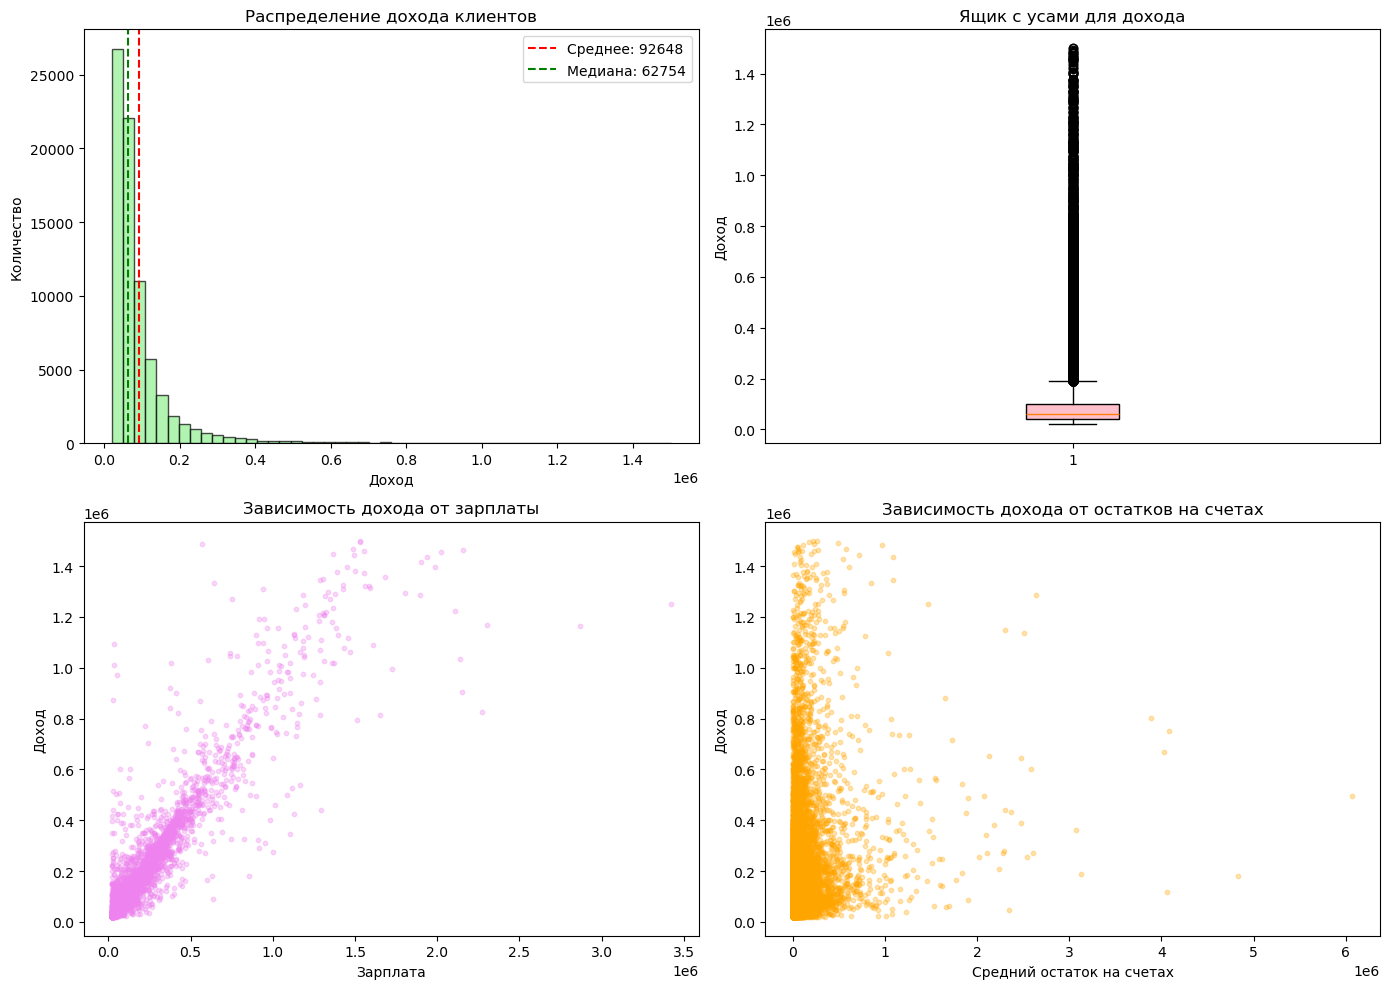

In [29]:
#Визуализация
#График распределения целевой переменной
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#Гистограмма дохода
axes[0, 0].hist(df_train['target'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 0].axvline(df_train['target'].mean(), color='red', linestyle='--', label=f'Среднее: {df_train["target"].mean():.0f}')
axes[0, 0].axvline(df_train['target'].median(), color='green', linestyle='--', label=f'Медиана: {df_train["target"].median():.0f}')
axes[0, 0].set_xlabel('Доход')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].set_title('Распределение дохода клиентов')
axes[0, 0].legend()

#Ящик с усами для дохода
box = axes[0, 1].boxplot(df_train['target'].dropna(), patch_artist=True)
for patch in box['boxes']:
    patch.set_facecolor('pink')
axes[0, 1].set_ylabel('Доход')
axes[0, 1].set_title('Ящик с усами для дохода')

#Зависимость дохода от зарплаты
if 'salary_6to12m_avg' in df_train.columns:
    axes[1, 0].scatter(df_train['salary_6to12m_avg'], df_train['target'], alpha=0.3, s=10, color='violet')
    axes[1, 0].set_xlabel('Зарплата')
    axes[1, 0].set_ylabel('Доход')
    axes[1, 0].set_title('Зависимость дохода от зарплаты')

#Зависимость дохода от остатков на счетах
if 'curr_rur_amt_cm_avg' in df_train.columns:
    axes[1, 1].scatter(df_train['curr_rur_amt_cm_avg'], df_train['target'], alpha=0.3, s=10, color='orange')
    axes[1, 1].set_xlabel('Средний остаток на счетах')
    axes[1, 1].set_ylabel('Доход')
    axes[1, 1].set_title('Зависимость дохода от остатков на счетах')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=300)
plt.show()

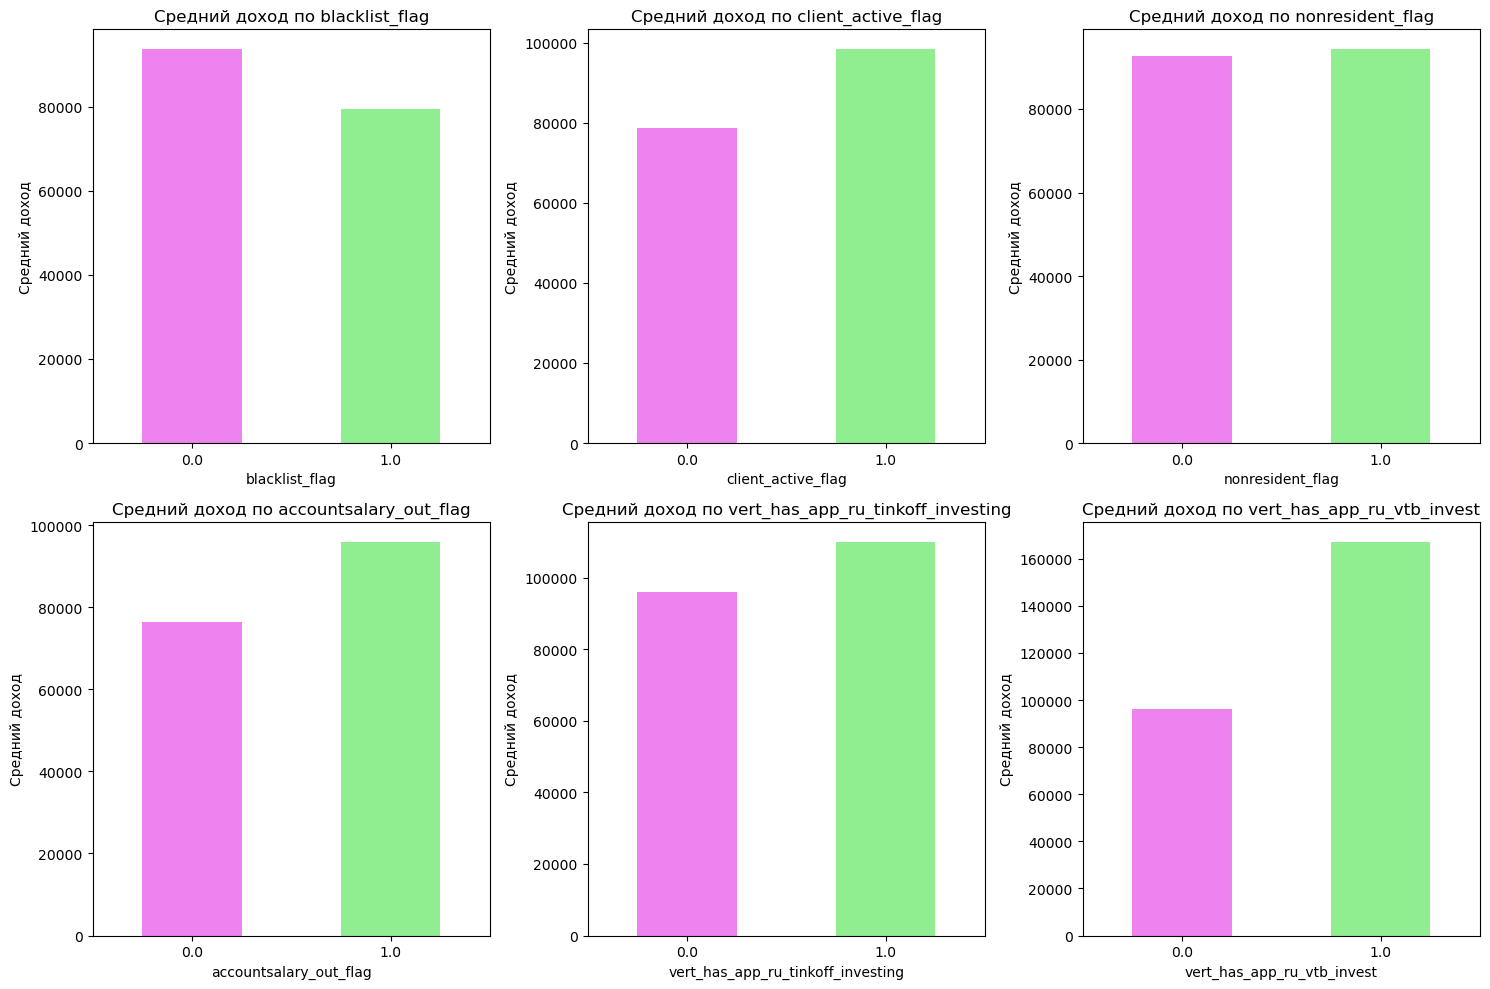

In [30]:
#Анализ бинарных признаков
binary_present = [col for col in binary_cols if col in df_train.columns]

if binary_present:
    n_cols = min(len(binary_present), 6)
    n_rows = (n_cols + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten()

    for idx in range(n_cols):
        col = binary_present[idx]
        df_train.groupby(col)['target'].mean().plot(kind='bar', ax=axes[idx], color=['violet', 'lightgreen'])
        axes[idx].set_title(f'Средний доход по {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Средний доход')
        axes[idx].tick_params(axis='x', rotation=0)
    for idx in range(n_cols, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.savefig('binary_features.png', dpi=300)
    plt.show()

**Выводы**:

1. Размер данных:
   - Обучающая выборка: 76786 записей, 232 признаков
   - Тестовая выборка: 73214 записей, 222 признаков
   - Общих признаков: 222

2. Целевая переменная (доход):
   - Среднее: 92648.24
   - Медиана: 62754.13
   - Стандартное отклонение: 112408.98
   - Асимметрия: 5.43 (скошена вправо)
   - Эксцесс: 42.32

3. Качество данных:
   - Признаков с пропусками: 217
   - Признаков с >50% пропусков: 83
   - Записей с пропусками: 76786

4. Ключевые признаки (корреляция с доходом >0.2):

   - w: 0.716
   - bki_total_il_max_limit: 0.439
   - hdb_bki_active_pil_max_limit: 0.432
   - hdb_bki_total_pil_max_limit: 0.415
   - hdb_bki_total_ip_max_limit: 0.411
   - hdb_bki_total_max_limit: 0.396
   - hdb_bki_active_cc_max_limit: 0.366
   - hdb_bki_total_cc_max_limit: 0.335
   - hdb_bki_other_active_ip_outstanding: 0.329


6. Потенциально важные закономерности:
   - Доход сильно зависит от региона проживания
   - Активность в мобильном приложении выше у богатых клиентов
   - Наличие просрочек снижает доход
   - Чем выше траты, тем выше доход